Matias CColque: Codigo Tarea 1.

In [ ]:
#SUBIDA DE ARCHIVO
from google.colab import files
uploaded = files.upload()

Saving Musical_Instruments (1).jsonl to Musical_Instruments (1).jsonl


In [ ]:
import pandas as pd

df = pd.read_json("Musical_Instruments (1).jsonl", lines=True)

print(df.head())

   rating                                   title  \
0       5                     Love these speakers   
1       4                        Good Quick Shine   
2       5       Tamborine - good value for price.   
3       4                            great guitar   
4       5  Beautiful, rich sound and easy to play   

                                                text images        asin  \
0             Love these speakers... loud and clear!     []  B076ZZ131M   
1  I don't know that it is a whole lot better tha...     []  B000A6ASQ0   
2  Sturdy and Easy to hold, grandbaby is 4yrs old...     []  B092DHKPHV   
3  arrived with strings. tuned it up. plugged it ...     []  B07W463J3K   
4  This guitar is so easy to play and has a rich,...     []  B0002GXZK4   

  parent_asin                       user_id               timestamp  \
0  B076ZZ131M  AFLN75KKZQI5VDG3K7JJ3AAPDROQ 2021-06-06 01:53:09.946   
1  B07J5FVQNT  AFVR4F37E2RJXXECR22JNUVKIQPQ 2013-08-16 02:06:25.000   
2  B092DHKPHV  AG

In [ ]:
#SELECCION DE 50% DE DATOS AL AZAR

# Carga DE datos
df = pd.read_json("Musical_Instruments (1).jsonl", lines=True)
RUT = 21764927

# Tomar 50% aleatorio
df_50 = df.sample(frac=0.5, random_state=RUT)

# Resetear índice (buena práctica)
df_50 = df_50.reset_index(drop=True)

print(df_50.shape)

(67500, 10)


In [ ]:
df_50.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Exactly what I was wanting.,Bought these for a guitar amplifier I bought a...,[],B01FDHAB3U,B075B5BMPF,AE4MDHTMWO6UCGS22G6DAUASZWAA,2020-12-18 22:17:03.584,0,True
1,4,Good quality BUT...,This could be a five-star product. It works we...,[],B06XWV9CCQ,B0B6HQR6H3,AHFBDZMQKESWRQ2WPFKO27AK4WGQ,2022-08-15 21:05:12.572,6,True
2,5,Easy and fun to use!,"The mics were good for the price you pay, and ...",[],B08ZXH4X95,B0BTCQBY83,AH4HNQLJGFG3SBZHQ6CGFVUZ3MBQ,2022-12-26 17:46:33.614,0,True
3,5,Works Great with No Issues so Far,"Great product, I use it every single day and h...",[],B01MQ0BK8R,B07QFKS28M,AGCM2525U47QOQM3QR5PIWMOBQXQ,2017-05-27 17:48:03.000,0,True
4,1,Terrible Audio after 2 months steady use,"This cable was perfectly fine initially, but I...",[],B01JNLTTKS,B06X9KG3HW,AEIIENAC24VOWESWAOTTGQBKRDSA,2023-05-01 20:59:11.144,0,True


In [ ]:
#(A)
import numpy as np

class LinearRegression:

    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        # Agregar columna de 1s (intercepto)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Fórmula de mínimos cuadrados
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta

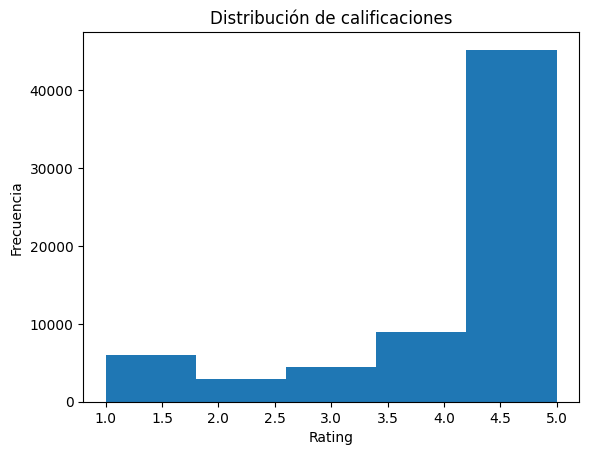

In [ ]:
#(B)
import matplotlib.pyplot as plt
plt.hist(df_50["rating"], bins=5)
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.title("Distribución de calificaciones")
plt.show()

In [ ]:
#Recoleccion de métricas
mean_rating = df_50["rating"].mean()
var_rating = df_50["rating"].var()

print("Promedio:", mean_rating)
print("Varianza:", var_rating)

Promedio: 4.2495259259259255
Varianza: 1.6516723926230494


In [ ]:
#(C) Preparación de los datos
df_model = df_50.copy()

# Variable objetivo
y = df_model["rating"].values

# Convertir booleano a 0/1
df_model["verified_purchase"] = df_model["verified_purchase"].astype(int)

# Crear largo de reseña
df_model["length_of_review"] = df_model["text"].apply(lambda x: len(str(x).split()))

# Matriz de características
X = df_model[["verified_purchase", "helpful_vote", "length_of_review"]].values

In [ ]:
#(C)
from sklearn.model_selection import train_test_split
#División de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


In [ ]:
#Preparar modelo
model = LinearRegression()
model.fit(X_train, y_train)

print("Theta:", model.theta)

Theta: [ 4.18382794e+00  1.29150313e-01 -3.15014875e-04 -1.21494074e-03]


In [ ]:
#Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
#Metricas pedidas
import numpy as np

def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return mse, rmse, mae, r2

mse_train, rmse_train, mae_train, r2_train = metrics(y_train, y_train_pred)
mse_test, rmse_test, mae_test, r2_test = metrics(y_test, y_test_pred)

print("Modelo de entrenamiento:", mse_train, rmse_train, mae_train, r2_train)
print("Modelo de testeo:", mse_test, rmse_test, mae_test, r2_test)

Modelo de entrenamiento: 1.6410948386372601 1.2810522388401107 0.9974946638087193 0.0065107063427459755
Modelo de testeo: 1.635179175658229 1.278741246561723 0.993614928239917 0.009474348440751346


# **(D)**

In [ ]:
#Cargamos paquetes extremadamente necesarios para este código
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Valores de lambda
lambdas = np.logspace(-4, 2, 20)

mse_train_ridge = []
mse_test_ridge = []

mse_train_lasso = []
mse_test_lasso = []

norm_ridge = []
norm_lasso = []

for l in lambdas:
    # Ridge
    ridge = Ridge(alpha=l)
    ridge.fit(X_train, y_train)

    y_train_pred = ridge.predict(X_train)
    y_test_pred = ridge.predict(X_test)

    mse_train_ridge.append(mean_squared_error(y_train, y_train_pred))
    mse_test_ridge.append(mean_squared_error(y_test, y_test_pred))
    norm_ridge.append(np.linalg.norm(ridge.coef_))

    # Lasso
    lasso = Lasso(alpha=l, max_iter=10000)
    lasso.fit(X_train, y_train)

    y_train_pred = lasso.predict(X_train)
    y_test_pred = lasso.predict(X_test)

    mse_train_lasso.append(mean_squared_error(y_train, y_train_pred))
    mse_test_lasso.append(mean_squared_error(y_test, y_test_pred))
    norm_lasso.append(np.linalg.norm(lasso.coef_))

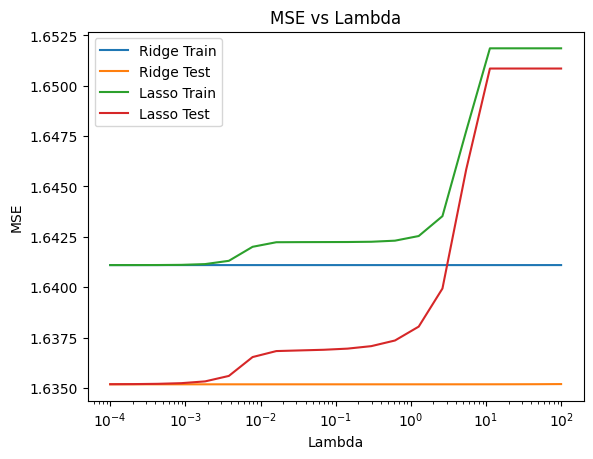

In [ ]:
plt.plot(lambdas, mse_train_ridge, label="Ridge Train")
plt.plot(lambdas, mse_test_ridge, label="Ridge Test")
plt.plot(lambdas, mse_train_lasso, label="Lasso Train")
plt.plot(lambdas, mse_test_lasso, label="Lasso Test")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.legend()
plt.title("MSE vs Lambda")
plt.show()

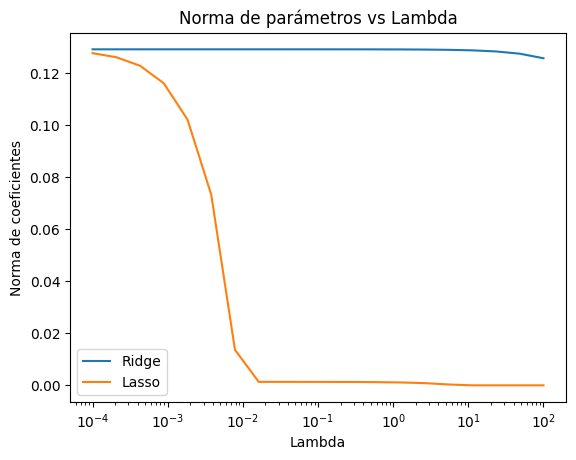

In [ ]:
plt.plot(lambdas, norm_ridge, label="Ridge")
plt.plot(lambdas, norm_lasso, label="Lasso")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Norma de coeficientes")
plt.legend()
plt.title("Norma de parámetros vs Lambda")
plt.show()

# **(E)**

                   verified_purchase  helpful_vote  length_of_review
verified_purchase           1.000000     -0.016684         -0.236985
helpful_vote               -0.016684      1.000000          0.182706
length_of_review           -0.236985      0.182706          1.000000


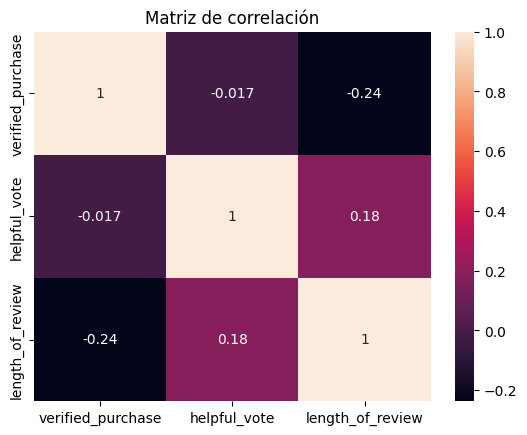

In [ ]:
#Paquetes necesarios para la creación de la matriz de correlación
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear DataFrame solo con variables predictoras
df_corr = df_model[["verified_purchase", "helpful_vote", "length_of_review"]]

# Matriz de correlación
corr_matrix = df_corr.corr()

print(corr_matrix)

# Heatmap (opcional pero recomendado)
sns.heatmap(corr_matrix, annot=True)
plt.title("Matriz de correlación")
plt.show()

# **(F)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustar solo con train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#MCO con datos escalados
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_train_pred = model_scaled.predict(X_train_scaled)
y_test_pred = model_scaled.predict(X_test_scaled)

mse_train, rmse_train, mae_train, r2_train = metrics(y_train, y_train_pred)
mse_test, rmse_test, mae_test, r2_test = metrics(y_test, y_test_pred)

print("MCO escalado:", mse_train, rmse_train, mae_train, r2_train)
print("MCO test:", mse_test, rmse_test, mae_test, r2_test)

MCO escalado: 1.6410948386372604 1.2810522388401109 0.9974946638087069 0.0065107063427457534
MCO test: 1.6351791756582288 1.2787412465617227 0.9936149282399045 0.009474348440751568


In [ ]:
from sklearn.linear_model import Ridge, Lasso
#Ridge y Lasso escalado
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.01, max_iter=10000)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

# Predicciones
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

print("Ridge MSE:", np.mean((y_test - y_pred_ridge)**2))
print("Lasso MSE:", np.mean((y_test - y_pred_lasso)**2))

Ridge MSE: 1.6351792600034785
Lasso MSE: 1.6360089391000268


# **(g)**

In [ ]:
# Convertir timestamp a datetime
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"])

# Extraer mes y año
df_model["month"] = df_model["timestamp"].dt.month
df_model["year"] = df_model["timestamp"].dt.year

In [ ]:
X_new = df_model[[
    "verified_purchase",
    "helpful_vote",
    "length_of_review",
    "month",
    "year"
]].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=123
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

modelos = {
    "MCO": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)}

resultados = {}

for name, model in modelos.items():
    if name == "MCO":
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

    resultados[name] = {
        "train": metrics(y_train, y_train_pred),
        "test": metrics(y_test, y_test_pred)}

for k, v in resultados.items():
    print(k, v)

MCO {'train': (np.float64(1.6378815818783203), np.float64(1.2797974768994977), np.float64(0.9980720783404893), np.float64(0.008455954181334824)), 'test': (np.float64(1.6305534795833891), np.float64(1.2769312744166732), np.float64(0.9936187998268186), np.float64(0.012276408720537924))}
Ridge {'train': (np.float64(1.637881581883164), np.float64(1.27979747690139), np.float64(0.9980721553461571), np.float64(0.008455954178402614)), 'test': (np.float64(1.6305536018456042), np.float64(1.276931322290124), np.float64(0.9936189066011181), np.float64(0.012276334659014787))}
Lasso {'train': (np.float64(1.6383276846992016), np.float64(1.2799717515239162), np.float64(0.9986235258966641), np.float64(0.008185891558516456)), 'test': (np.float64(1.631948379346791), np.float64(1.2774773498370886), np.float64(0.9941876739962299), np.float64(0.011431434654348926))}
ElasticNet {'train': (np.float64(1.6380140704939194), np.float64(1.2798492374080315), np.float64(0.9983549137364726), np.float64(0.008375747956